In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

ratings = pd.read_csv('../data/ratings.csv')
books = pd.read_csv('../data/books.csv')

user_counts = ratings['user_id'].value_counts()
active_users = user_counts[user_counts>=5].index
ratings = ratings[ratings['user_id'].isin(active_users)]

print(f"Ratings: {len(ratings):,}")
print(f"Users: {ratings['user_id'].nunique():,}")
print(f"Books: {ratings['book_id'].nunique():,}")
print(f"PyTorch version: {torch.__version__}")

Ratings: 932,940
Users: 35,710
Books: 10,000
PyTorch version: 2.12.0+cpu


In [18]:
user_ids = ratings['user_id'].unique()
book_ids = ratings['book_id'].unique()

user2idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
book2idx = {book_id: idx for idx, book_id in enumerate(book_ids)}

ratings['user_idx'] = ratings['user_id'].map(user2idx)
ratings['book_idx'] = ratings['book_id'].map(book2idx)

n_users = len(user2idx)
n_books = len(book2idx)

print(f"User index range: 0 to {n_users - 1}")
print(f"Book index range: 0 to {n_books - 1}")
print(ratings[['user_id', 'user_idx', 'book_id', 'book_idx', 'rating']].head())

User index range: 0 to 35709
Book index range: 0 to 9999
   user_id  user_idx  book_id  book_idx  rating
0      314         0        1         0       5
1      439         1        1         0       3
2      588         2        1         0       5
3     1169         3        1         0       4
4     1185         4        1         0       4


In [19]:
# Train test split
train_data, test_data = train_test_split(
    ratings, test_size=0.2, random_state=42
)
print(f"Train: {len(train_data):,}")
print(f"Test: {len(test_data):,}")

Train: 746,352
Test: 186,588


In [20]:
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.books = torch.tensor(df['book_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self,idx):
        return self.users[idx],self.books[idx],self.ratings[idx]

train_dataset = RatingsDataset(train_data)
test_dataset = RatingsDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 729
Test batches: 183


In [21]:
class MatrixFactorisation(nn.Module):
    def __init__(self, n_users, n_books, embedding_dim=50):
        super().__init__()
        self.user_embeddings = nn.Embedding(n_users, embedding_dim)
        self.book_embeddings = nn.Embedding(n_books, embedding_dim)
        self.user_bias = nn.Embedding(n_users,1)
        self.book_bias = nn.Embedding(n_books, 1)

        nn.init.normal_(self.user_embeddings.weight, std=0.01)
        nn.init.normal_(self.book_embeddings.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.book_bias.weight)

    def forward(self, user_idx, book_idx):
        user_emb = self.user_embeddings(user_idx)
        book_emb = self.book_embeddings(book_idx)
        user_b = self.user_bias(user_idx).squeeze()
        book_b = self.book_bias(book_idx).squeeze()

        dot = (user_emb*book_emb).sum(dim=1)
        prediction = dot + user_b +book_b
        return prediction

model = MatrixFactorisation(n_users, n_books, embedding_dim=50)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

MatrixFactorisation(
  (user_embeddings): Embedding(35710, 50)
  (book_embeddings): Embedding(10000, 50)
  (user_bias): Embedding(35710, 1)
  (book_bias): Embedding(10000, 1)
)

Total parameters: 2,331,210


In [22]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
criterion = nn.MSELoss()
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for user_idx, book_idx, rating in loader:
        optimizer.zero_grad()
        prediction = model(user_idx, book_idx)
        loss = criterion(prediction, rating)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss/ len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for user_idx, book_idx, rating in loader:
            prediction = model(user_idx, book_idx)
            loss = criterion(prediction, rating)
            total_loss += loss.item()
        return total_loss / len(loader)

print("Training loop defined sucessfully")

Training loop defined sucessfully


In [23]:
n_epochs = 10
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    test_loss = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"Epoch {epoch+1:02d}/{n_epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
print("\nTraining complete.")

Epoch 01/10 | Train Loss: 13.2064 | Test Loss: 7.7673
Epoch 02/10 | Train Loss: 3.4819 | Test Loss: 1.5326
Epoch 03/10 | Train Loss: 1.0118 | Test Loss: 0.8967
Epoch 04/10 | Train Loss: 0.7169 | Test Loss: 0.7653
Epoch 05/10 | Train Loss: 0.6359 | Test Loss: 0.7207
Epoch 06/10 | Train Loss: 0.5942 | Test Loss: 0.7032
Epoch 07/10 | Train Loss: 0.5628 | Test Loss: 0.6956
Epoch 08/10 | Train Loss: 0.5336 | Test Loss: 0.6924
Epoch 09/10 | Train Loss: 0.5042 | Test Loss: 0.6946
Epoch 10/10 | Train Loss: 0.4737 | Test Loss: 0.6957

Training complete.


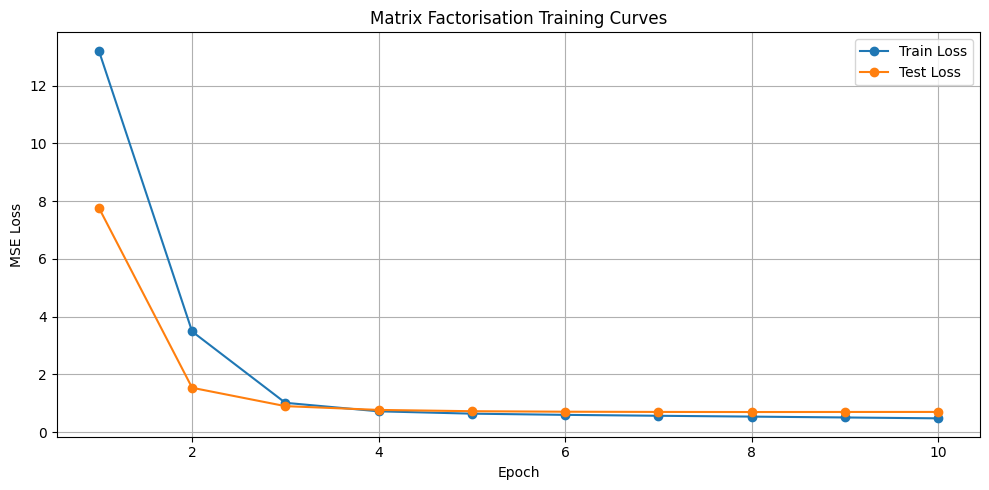

Best test loss: 0.6924 at epoch 8


In [25]:
plt.figure(figsize=(10,5))
plt.plot(range(1,n_epochs+1),train_losses, label='Train Loss', marker = 'o')
plt.plot(range(1,n_epochs+1),test_losses, label='Test Loss', marker = 'o')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Matrix Factorisation Training Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print(f"Best test loss: {min(test_losses):.4f} at epoch {test_losses.index(min(test_losses))+1}")

In [26]:
def recommend_books(model, user_idx, books_df, book2idx, n=10):
    model.eval()
    with torch.no_grad():
        user_tensor = torch.tensor([user_idx] * len(book2idx), dtype=torch.long)
        book_tensor = torch.tensor(list(book2idx.values()), dtype=torch.long)
        predictions = model(user_tensor, book_tensor)
    
    top_book_indices = predictions.argsort(descending=True)[:n].numpy()
    idx2book = {v: k for k, v in book2idx.items()}
    top_book_ids = [idx2book[idx] for idx in top_book_indices]
    
    recommended = books_df[books_df['id'].isin(top_book_ids)][['original_title', 'authors', 'average_rating']]
    return recommended

sample_user = 0
recommendations = recommend_books(model, sample_user, books, book2idx)
print(f"Top 10 recommendations for user index {sample_user}:")
print(recommendations.to_string())

Top 10 recommendations for user index 0:
                                                        original_title                                                               authors  average_rating
982                                           Between the World and Me                                                      Ta-Nehisi Coates            4.40
1009     The Essential Calvin and Hobbes: A Calvin and Hobbes Treasury                                                        Bill Watterson            4.65
1379                                                 The Complete Maus                                                        Art Spiegelman            4.53
1787                      The Calvin and Hobbes Tenth Anniversary Book                                                        Bill Watterson            4.63
2839                                                         Homegoing                                                             Yaa Gyasi            4.41
3627             

In [27]:
import os

os.makedirs('../models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'user2idx': user2idx,
    'book2idx': book2idx,
    'n_users': n_users,
    'n_books': n_books,
    'embedding_dim': 50,
    'train_losses': train_losses,
    'test_losses': test_losses,
}, '../models/matrix_factorisation.pt')

print("Model saved to ../models/matrix_factorisation.pt")
print(f"File size: {os.path.getsize('../models/matrix_factorisation.pt') / 1024 / 1024:.1f} MB")

Model saved to ../models/matrix_factorisation.pt
File size: 11.2 MB
